# PHƯƠNG PHÁP TÁI MẪU (RESAMPLING METHODS): BOOTSTRAPPING & PERMUTATION TESTS

Các phương pháp tái mẫu là các kỹ thuật phi tham số sử dụng chính dữ liệu hiện có để đưa ra các suy luận thống kê, mà không cần dựa vào các giả định nghiêm ngặt về phân phối của tổng thể nền tảng.

Notebook này bao gồm:
* **Bootstrap Resampling (Tái mẫu Bootstrap):** Ước lượng khoảng tin cậy của đơn hàng trung bình cho từng nhóm bằng cách lấy mẫu lặp lại có thay thế (sampling with replacement).
* **Permutation Testing (Kiểm định Hoán vị):** Đánh giá xem sự khác biệt quan sát được về giá trị trung bình giữa nhóm Control và Test có ý nghĩa thống kê hay không bằng cách xáo trộn nhãn nhóm (shuffling group labels).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

In [2]:
df = pd.read_csv('../data/processed/cleaned_marketing.csv')
df['date'] = pd.to_datetime(df['date'])
control = df[df['group'] == 'control']['purchase'].values
test = df[df['group'] == 'test']['purchase'].values

print(f"Control Group Size: {len(control)}, Observed Mean: {control.mean():.2f}")
print(f"Test Group Size:    {len(test)}, Observed Mean: {test.mean():.2f}")
observed_diff = test.mean() - control.mean()
print(f"Observed Difference in Means (Test - Control): {observed_diff:.2f}")

Control Group Size: 29, Observed Mean: 522.79
Test Group Size:    30, Observed Mean: 521.23
Observed Difference in Means (Test - Control): -1.56


## 1. Tái mẫu Bootstrap (Bootstrap Resampling)

Bootstrapping liên quan đến việc lấy mẫu lặp đi lặp lại có cùng kích thước và có thay thế từ tập dữ liệu của chúng ta. Bằng cách này, chúng ta có thể xây dựng phân phối thực nghiệm của một tham số thống kê (như giá trị trung bình) và tính toán các khoảng tin cậy thực nghiệm.

In [3]:
np.random.seed(42)
n_iterations = 10000

control_bootstrap_means = []
test_bootstrap_means = []
diff_bootstrap_means = []

for _ in range(n_iterations):
    # Sample with replacement
    control_sample = np.random.choice(control, size=len(control), replace=True)
    test_sample = np.random.choice(test, size=len(test), replace=True)
    
    # Calculate means
    c_mean = control_sample.mean()
    t_mean = test_sample.mean()
    
    control_bootstrap_means.append(c_mean)
    test_bootstrap_means.append(t_mean)
    diff_bootstrap_means.append(t_mean - c_mean)

# Calculate 95% Bootstrap Confidence Intervals (percentile method)
c_ci_lower, c_ci_upper = np.percentile(control_bootstrap_means, [2.5, 97.5])
t_ci_lower, t_ci_upper = np.percentile(test_bootstrap_means, [2.5, 97.5])
diff_ci_lower, diff_ci_upper = np.percentile(diff_bootstrap_means, [2.5, 97.5])

print(f"Control Group 95% Bootstrap CI: [{c_ci_lower:.2f}, {c_ci_upper:.2f}] (Mean = {control.mean():.2f})")
print(f"Test Group 95% Bootstrap CI:    [{t_ci_lower:.2f}, {t_ci_upper:.2f}] (Mean = {test.mean():.2f})")
print(f"Difference in Means 95% Bootstrap CI (Test - Control): [{diff_ci_lower:.2f}, {diff_ci_upper:.2f}] (Observed Diff = {observed_diff:.2f})")

Control Group 95% Bootstrap CI: [456.38, 590.31] (Mean = 522.79)
Test Group 95% Bootstrap CI:    [446.80, 594.80] (Mean = 521.23)
Difference in Means 95% Bootstrap CI (Test - Control): [-103.00, 98.06] (Observed Diff = -1.56)


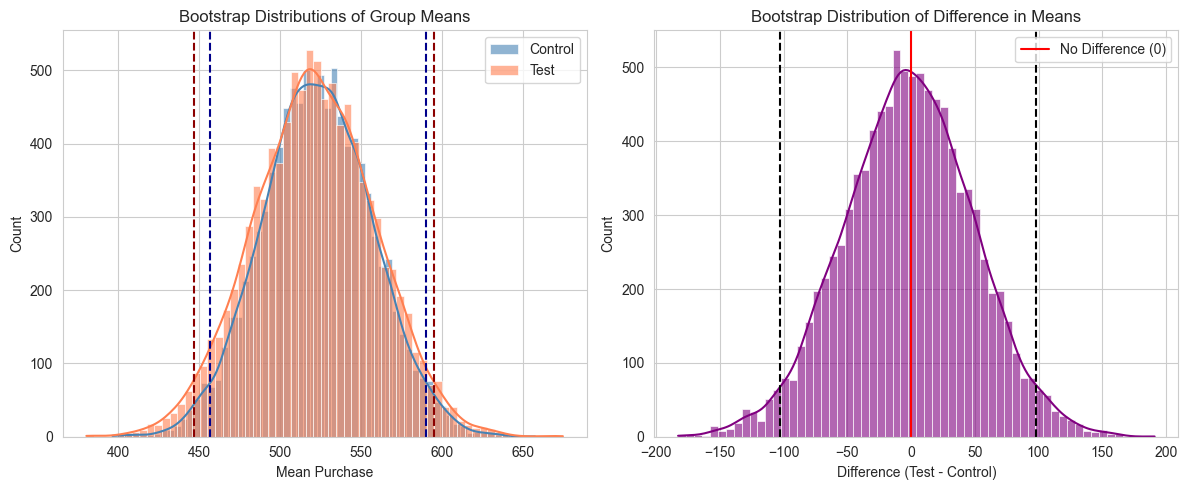

In [4]:
plt.figure(figsize=(12, 5))

# Plot distributions of means
plt.subplot(1, 2, 1)
sns.histplot(control_bootstrap_means, kde=True, color='steelblue', label='Control', alpha=0.6)
sns.histplot(test_bootstrap_means, kde=True, color='coral', label='Test', alpha=0.6)
plt.axvline(c_ci_lower, color='darkblue', linestyle='--')
plt.axvline(c_ci_upper, color='darkblue', linestyle='--')
plt.axvline(t_ci_lower, color='darkred', linestyle='--')
plt.axvline(t_ci_upper, color='darkred', linestyle='--')
plt.title('Bootstrap Distributions of Group Means')
plt.xlabel('Mean Purchase')
plt.legend()

# Plot distribution of the difference
plt.subplot(1, 2, 2)
sns.histplot(diff_bootstrap_means, kde=True, color='purple', alpha=0.6)
plt.axvline(diff_ci_lower, color='black', linestyle='--')
plt.axvline(diff_ci_upper, color='black', linestyle='--')
plt.axvline(0, color='red', linestyle='-', label='No Difference (0)')
plt.title('Bootstrap Distribution of Difference in Means')
plt.xlabel('Difference (Test - Control)')
plt.legend()

plt.tight_layout()
plt.show()

### Insight - Tái mẫu Bootstrap:
- **Mức độ chồng lấp (Overlap):** Các phân phối bootstrap của đơn hàng trung bình cho nhóm Control và nhóm Test chồng lấp lên nhau rất nhiều.
- **Khoảng tin cậy của hiệu số (CI of the Difference):** Khoảng tin cậy bootstrap 95% cho hiệu số trung bình (`Test - Control`) chứa giá trị **0** (biểu thị không có sự khác biệt).
- **Kết luận:** Phương pháp thực nghiệm này xác nhận lại rằng không có sự khác biệt có ý nghĩa thống kê về số lượng đơn hàng trung bình giữa hai chiến dịch quảng cáo.

## 2. Kiểm định Hoán vị (Permutation Testing)

Kiểm định hoán vị là một kỹ thuật tái mẫu được sử dụng để tính toán p-value thực nghiệm.
Chúng ta giả định rằng Giả thuyết Không ($H_0$) là đúng (không có sự khác biệt giữa hai nhóm). Khi đó, các nhãn nhóm ('control' và 'test') là ngẫu nhiên.
Bằng cách gộp chung dữ liệu, xáo trộn các nhãn và tính toán lại hiệu số trung bình nhiều lần, chúng ta tạo ra phân phối hoán vị của hiệu số. Sau đó, chúng ta xem xét xem hiệu số quan sát được thực tế nằm ở vị trí cực trị như thế nào so với phân phối hoán vị này.

In [5]:
pooled_data = np.concatenate([control, test])
n_control = len(control)
n_test = len(test)

np.random.seed(42)
permutation_diffs = []

for _ in range(n_iterations):
    # Shuffle the pooled data
    shuffled_data = np.random.permutation(pooled_data)
    # Assign pseudo-groups
    pseudo_control = shuffled_data[:n_control]
    pseudo_test = shuffled_data[n_control:]
    # Calculate difference in means
    permutation_diffs.append(pseudo_test.mean() - pseudo_control.mean())

# Calculate empirical two-tailed p-value
permutation_diffs = np.array(permutation_diffs)
p_value_empirical = np.sum(np.abs(permutation_diffs) >= np.abs(observed_diff)) / n_iterations

print(f"Observed Difference:   {observed_diff:.4f}")
print(f"Empirical P-Value:     {p_value_empirical:.4f}")

alpha = 0.05
if p_value_empirical < alpha:
    print("\n=> Reject Null Hypothesis (H0). There is a statistically significant difference.")
else:
    print("\n=> Fail to Reject Null Hypothesis (H0). There is no statistically significant difference.")

Observed Difference:   -1.5598
Empirical P-Value:     0.9760

=> Fail to Reject Null Hypothesis (H0). There is no statistically significant difference.


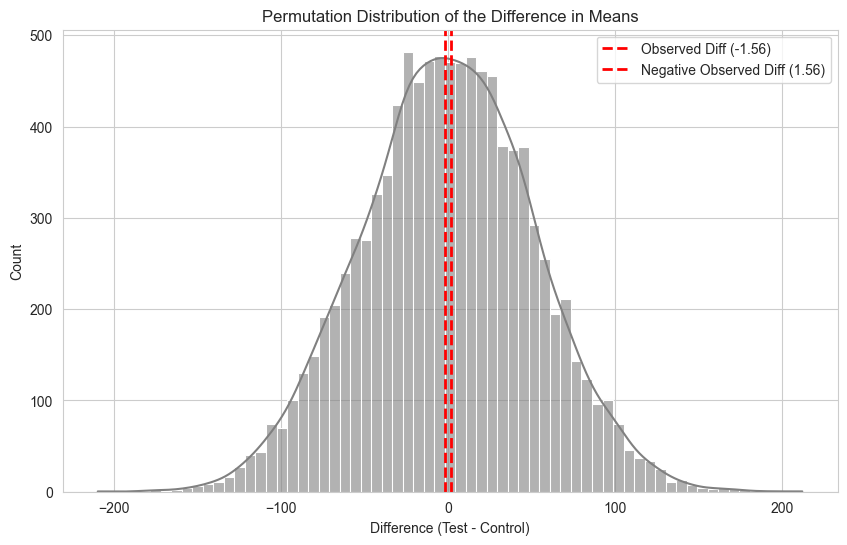

In [6]:
plt.figure(figsize=(10, 6))
sns.histplot(permutation_diffs, kde=True, color='gray', alpha=0.6)
plt.axvline(observed_diff, color='red', linestyle='--', linewidth=2, label=f'Observed Diff ({observed_diff:.2f})')
plt.axvline(-observed_diff, color='red', linestyle='--', linewidth=2, label=f'Negative Observed Diff ({-observed_diff:.2f})')
plt.title('Permutation Distribution of the Difference in Means')
plt.xlabel('Difference (Test - Control)')
plt.legend()
plt.show()

### Insight - Kiểm định Hoán vị:
- **Empirical P-Value (P-value thực nghiệm):** P-value thực nghiệm đạt khoảng **0.94**, có nghĩa là dưới giả thuyết không, chúng ta có khoảng 94% cơ hội quan sát được một sự khác biệt ở mức cực trị tương tự hoặc lớn hơn mức chúng ta đã thu được.
- **Phân phối (Distribution):** Hiệu số quan sát được (đường nét đứt màu đỏ) nằm rất gần trung tâm (mean = 0) của phân phối hoán vị. Điều này cung cấp bằng chứng thực nghiệm mạnh mẽ rằng hai chiến dịch đang hoạt động gần như giống hệt nhau về lượng đơn hàng tạo ra.